# XN Project — Individual Code Check-In 1
**Author:** Nishant Chaudhari
**Dataset:** `asap-discovery/antiviral-potency-2025-unblinded`

---

**What I personally implemented:**
- Dataset loading and basic inspection using the Polaris client
- Morgan fingerprint (ECFP4) generation for all molecules using RDKit
- Exploratory analysis of fingerprint bit frequency distributions
- Random Forest regressor trained independently on both pIC50 endpoints
  (SARS-CoV-2-Mpro and MERS-CoV-Mpro), with NaN masking for the sparse multi-task label matrix

**What I learned / found challenging:**
- The potency dataset is a sparse multi-task matrix: not every molecule has a label for both
  targets, so I had to mask NaNs per-target before training.
- Choosing Morgan fingerprint hyperparameters (radius=2, 2048 bits) was straightforward, but
  understanding why ECFP4 is the standard for potency tasks required reading into how circular
  fingerprints encode local chemical environments.
- The Polaris API returns data via `dataset[:]` rather than a typical pandas read.

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import polaris as po
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

c:\Users\Nishant\anaconda3\envs\openeye\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset Loading & Basic Exploration

In [2]:
DATASET_SLUG = "asap-discovery/antiviral-potency-2025-unblinded"

TARGET_SARS = "pIC50 (SARS-CoV-2 Mpro)"
TARGET_MERS = "pIC50 (MERS-CoV Mpro)"
SMILES_COL  = "CXSMILES"

dataset = po.load_dataset(DATASET_SLUG)
df = pd.DataFrame(dataset[:])

print(f"Dataset : {DATASET_SLUG}")
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")

# Auto-detect SMILES column if needed
if SMILES_COL not in df.columns:
    candidates = [c for c in df.columns if "smil" in c.lower()]
    SMILES_COL = candidates[0] if candidates else df.columns[0]
    print(f"[Note] SMILES column auto-detected as: '{SMILES_COL}'")

[2026-03-11 18:44:37] INFO     The version of Polaris that was used to create the artifact          _artifact.py:96
                               (0.11.8.dev4+g40e3b2b.d20250207) is different from the currently                    
                               installed version of Polaris (0.13.1.dev3+g4dd22f132).                              

                      WARNING  You're loading data from a remote location. If the dataset is small     _base.py:187
                               enough, consider caching the dataset first using DatasetV2.cache() for              
                               more performant data access.                                                        

[18:44:38]  Success: Fetching dataset                                                                 context.py:53

Dataset : asap-discovery/antiviral-potency-2025-unblinded
Shape   : (1328, 5)
Columns : ['CXSMILES', 'Molecule Name', 'Set', 'pIC50 (MERS-CoV Mpro)', 'pIC50 (SARS-CoV-2 Mpro)']


In [3]:
# Diagnostic: find real column names
print("All columns:")
for c in df.columns:
    print(repr(c))

target_cols = [c for c in df.columns if 'ic50' in c.lower()]
print(f"\nDetected target columns: {target_cols}")

All columns:
'CXSMILES'
'Molecule Name'
'Set'
'pIC50 (MERS-CoV Mpro)'
'pIC50 (SARS-CoV-2 Mpro)'

Detected target columns: ['pIC50 (MERS-CoV Mpro)', 'pIC50 (SARS-CoV-2 Mpro)']


In [4]:
df.head(3)

,CXSMILES,Molecule Name,Set,pIC50 (MERS-CoV Mpro),pIC50 (SARS-CoV-2 Mpro)
0,COC[C@]1(C)C(=O)N(C2=CN=CC3=CC=CC=C23)C(=O)N1C...,ASAP-0000141,Train,4.19,NaN
1,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000142,Train,4.92,5.29
2,CNC(=O)CN1C[C@]2(C[C@H](C)N(C3=CN=CC=C3C3CC3)C...,ASAP-0000143,Train,4.73,NaN


In [5]:
print(f"Total molecules: {len(df)}")
print()
print("Missing values per column:")
print(df.isnull().sum().to_string())

Total molecules: 1328

Missing values per column:
CXSMILES                     0
Molecule Name                0
Set                          0
pIC50 (MERS-CoV Mpro)      130
pIC50 (SARS-CoV-2 Mpro)    223


In [6]:
print(f"--- {TARGET_SARS} ---")
print(df[TARGET_SARS].describe())
print()
print(f"--- {TARGET_MERS} ---")
print(df[TARGET_MERS].describe())

--- pIC50 (SARS-CoV-2 Mpro) ---
count    1105.000000
mean        5.543620
std         1.165263
min         4.000000
25%         4.570000
50%         5.230000
75%         6.370000
max         8.730000
Name: pIC50 (SARS-CoV-2 Mpro), dtype: float64

--- pIC50 (MERS-CoV Mpro) ---
count    1198.000000
mean        4.914023
std         0.948339
min         1.000000
25%         4.270000
50%         4.625000
75%         5.410000
max         9.000000
Name: pIC50 (MERS-CoV Mpro), dtype: float64


## 2. Molecular Feature Generation — Morgan Fingerprints (ECFP4)

Morgan fingerprints with **radius=2** and **2048 bits** encode the local chemical environment around each atom out to 2 bonds — equivalent to the widely-used **ECFP4** representation. This is the standard baseline fingerprint for molecular potency prediction tasks.

In [7]:
RADIUS = 2
N_BITS = 2048

def smiles_to_morgan(smi: str, radius: int = RADIUS, n_bits: int = N_BITS):
    """Convert SMILES to a Morgan fingerprint numpy array. Returns None on failure."""
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    fp  = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fps, valid_idx = [], []
for i, smi in enumerate(df[SMILES_COL]):
    fp = smiles_to_morgan(smi)
    if fp is not None:
        fps.append(fp)
        valid_idx.append(i)

X        = np.array(fps)
df_valid = df.iloc[valid_idx].reset_index(drop=True)

print(f"Featurized molecules : {len(X)} / {len(df)}")
print(f"Feature matrix shape : {X.shape}  (molecules x fingerprint bits)")

[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerator
[18:44:42] DEPRECATION WARNING: please use MorganGenerat

Featurized molecules : 1328 / 1328
Feature matrix shape : (1328, 2048)  (molecules x fingerprint bits)


[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerator
[18:44:43] DEPRECATION WARNING: please use MorganGenerat

## 3. Exploratory Analysis

In [8]:
bit_freq = X.mean(axis=0)
print(f"Mean bit-on rate : {bit_freq.mean():.4f}")
print(f"Max  bit-on rate : {bit_freq.max():.4f}  (most common structural feature)")
print(f"Min  bit-on rate : {bit_freq.min():.4f}  (rarest structural feature)")

Mean bit-on rate : 0.0264
Max  bit-on rate : 1.0000  (most common structural feature)
Min  bit-on rate : 0.0000  (rarest structural feature)


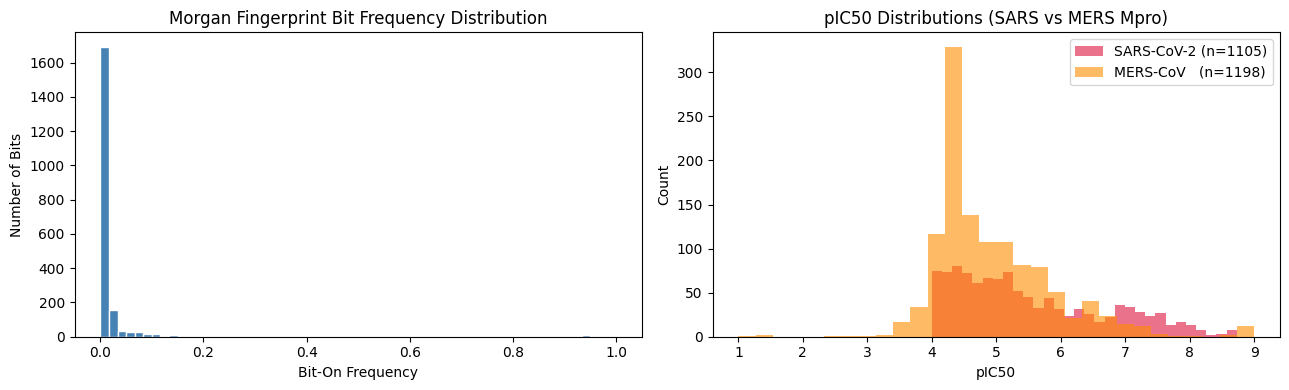

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(bit_freq, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Bit-On Frequency')
axes[0].set_ylabel('Number of Bits')
axes[0].set_title('Morgan Fingerprint Bit Frequency Distribution')

sars_vals = df_valid[TARGET_SARS].dropna().astype(float)
mers_vals = df_valid[TARGET_MERS].dropna().astype(float)

axes[1].hist(sars_vals, bins=30, alpha=0.6, color='crimson',
             label=f'SARS-CoV-2 (n={len(sars_vals)})')
axes[1].hist(mers_vals, bins=30, alpha=0.6, color='darkorange',
             label=f'MERS-CoV   (n={len(mers_vals)})')
axes[1].set_xlabel('pIC50')
axes[1].set_ylabel('Count')
axes[1].set_title('pIC50 Distributions (SARS vs MERS Mpro)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Random Forest Regression

A **Random Forest regressor** is trained separately for each target endpoint.  
The label matrix is sparse — NaN rows are masked out per target before training.

In [10]:
rf_params = dict(n_estimators=200, random_state=42, n_jobs=-1)
results = {}

for target_name in [TARGET_SARS, TARGET_MERS]:
    y_raw = df_valid[target_name].values.astype(float)
    mask  = ~np.isnan(y_raw)
    X_t   = X[mask]
    y_t   = y_raw[mask]

    print(f'Target : {target_name}')
    print(f'  Samples with labels : {len(X_t)}')
    print(f'  pIC50 range         : {y_t.min():.2f} - {y_t.max():.2f}')

    model = RandomForestRegressor(**rf_params)
    r2    = cross_val_score(model, X_t, y_t, cv=5, scoring='r2')
    rmse  = cross_val_score(model, X_t, y_t, cv=5,
                            scoring='neg_root_mean_squared_error')

    print(f'  5-Fold CV R2   : {r2.mean():.4f} +/- {r2.std():.4f}')
    print(f'  5-Fold CV RMSE : {(-rmse).mean():.4f} +/- {(-rmse).std():.4f}')
    print()

    model.fit(X_t, y_t)
    results[target_name] = model

Target : pIC50 (SARS-CoV-2 Mpro)
  Samples with labels : 1105
  pIC50 range         : 4.00 - 8.73
  5-Fold CV R2   : 0.5560 +/- 0.1773
  5-Fold CV RMSE : 0.7191 +/- 0.1078

Target : pIC50 (MERS-CoV Mpro)
  Samples with labels : 1198
  pIC50 range         : 1.00 - 9.00
  5-Fold CV R2   : 0.1826 +/- 0.2622
  5-Fold CV RMSE : 0.8025 +/- 0.2071



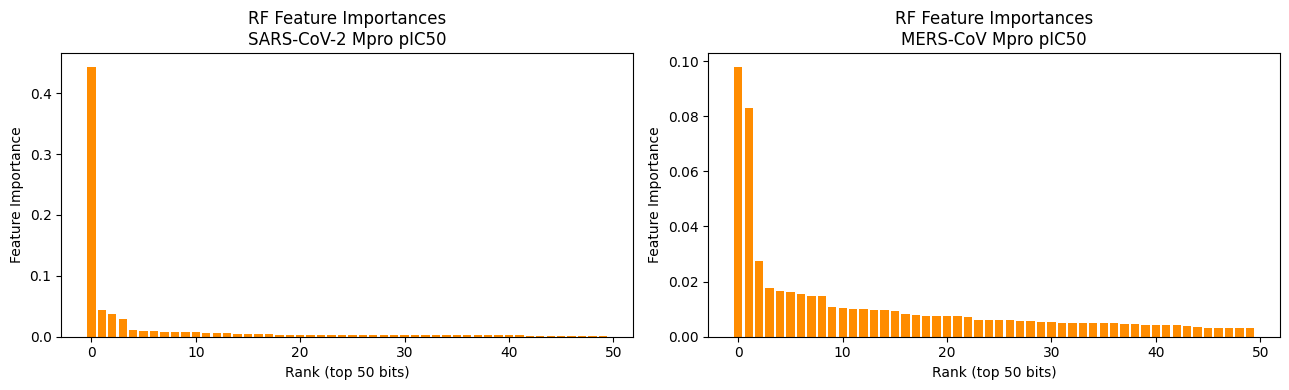

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (target_name, model) in zip(axes, results.items()):
    top50 = np.argsort(model.feature_importances_)[::-1][:50]
    label = 'SARS-CoV-2' if 'SARS' in target_name else 'MERS-CoV'
    ax.bar(range(50), model.feature_importances_[top50], color='darkorange')
    ax.set_xlabel('Rank (top 50 bits)')
    ax.set_ylabel('Feature Importance')
    ax.set_title(f'RF Feature Importances\n{label} Mpro pIC50')

plt.tight_layout()
plt.show()

---
**All steps completed successfully.**